# Data Loading Demo

This notebook demonstrates the custom PyTorch data loaders in `E:\dataloader` with simple matplotlib visualizations.

In [1]:
pip install torch

   ---------------------------------------- 0.0/113.7 MB ? eta -:--:--
    --------------------------------------- 1.8/113.7 MB 20.2 MB/s eta 0:00:06
   -- ------------------------------------- 7.9/113.7 MB 30.4 MB/s eta 0:00:04
   ----- ---------------------------------- 16.0/113.7 MB 31.5 MB/s eta 0:00:04
   -------- ------------------------------- 22.8/113.7 MB 31.4 MB/s eta 0:00:03
   --------- ------------------------------ 28.3/113.7 MB 29.9 MB/s eta 0:00:03
   ------------ --------------------------- 34.3/113.7 MB 29.9 MB/s eta 0:00:03
   ------------- -------------------------- 39.3/113.7 MB 28.7 MB/s eta 0:00:03
   --------------- ------------------------ 44.6/113.7 MB 28.1 MB/s eta 0:00:03
   ----------------- ---------------------- 50.1/113.7 MB 27.7 MB/s eta 0:00:03
   ------------------- -------------------- 54.3/113.7 MB 26.8 MB/s eta 0:00:03
   --------------------- ------------------ 60.0/113.7 MB 26.9 MB/s eta 0:00:02
   ----------------------- ---------------- 66.3/11

In [2]:
import sys
from pathlib import Path

# Make E:\dataloader importable
sys.path.append(r"E:\dataloader")

import matplotlib.pyplot as plt
import torch

from dataloader import DepthDataset, SuperResDataset, DomainAdaptDataset

In [3]:
# Roots
DEPTH_ROOT = r"E:\RS_DATASET\depth_npy"
HR_ROOT = r"E:\RS_DATASET\hr"
LR_X2_ROOT = r"E:\RS_DATASET\lr\x2"
LR_X4_ROOT = r"E:\RS_DATASET\lr\x4"
LR_X8_ROOT = r"E:\RS_DATASET\lr\x8"
NIGHT_ROOT = r"E:\RS_DATASET\night"

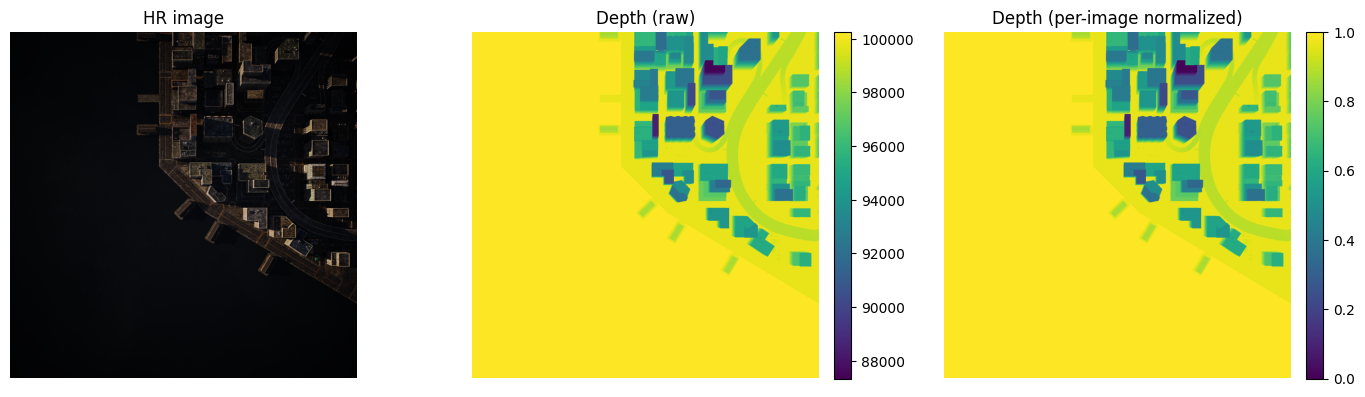

In [4]:
# Depth dataset (raw vs per-image normalized)
depth_raw = DepthDataset(DEPTH_ROOT, HR_ROOT, normalize_depth="raw")
depth_norm = DepthDataset(DEPTH_ROOT, HR_ROOT, normalize_depth="per_image_minmax")

sample_raw = depth_raw[0]
sample_norm = depth_norm[0]

img = sample_raw["image"].permute(1, 2, 0).numpy()
depth_r = sample_raw["depth"][0].numpy()
depth_n = sample_norm["depth"][0].numpy()

fig, axs = plt.subplots(1, 3, figsize=(14, 4))
axs[0].imshow(img)
axs[0].set_title("HR image")
axs[0].axis("off")

im1 = axs[1].imshow(depth_r)
axs[1].set_title("Depth (raw)")
axs[1].axis("off")
fig.colorbar(im1, ax=axs[1], fraction=0.046, pad=0.04)

im2 = axs[2].imshow(depth_n)
axs[2].set_title("Depth (per-image normalized)")
axs[2].axis("off")
fig.colorbar(im2, ax=axs[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

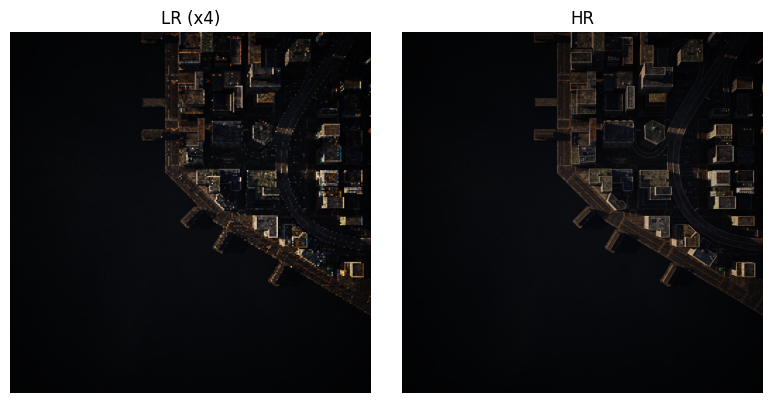

In [7]:
# Super-resolution example (x4)
sr = SuperResDataset(LR_X8_ROOT, HR_ROOT)
s = sr[0]

lr = s["lr"].permute(1, 2, 0).numpy()
hr = s["hr"].permute(1, 2, 0).numpy()

fig, axs = plt.subplots(1, 2, figsize=(8, 4))
axs[0].imshow(lr)
axs[0].set_title("LR (x4)")
axs[0].axis("off")

axs[1].imshow(hr)
axs[1].set_title("HR")
axs[1].axis("off")

plt.tight_layout()
plt.show()

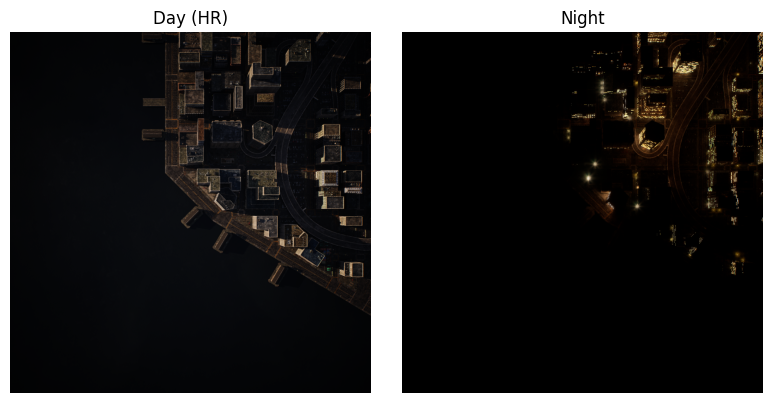

In [6]:
# Day -> Night domain adaptation (unpaired)
da = DomainAdaptDataset(HR_ROOT, NIGHT_ROOT, paired=False)
d = da[0]

day = d["day"].permute(1, 2, 0).numpy()
night = d["night"].permute(1, 2, 0).numpy()

fig, axs = plt.subplots(1, 2, figsize=(8, 4))
axs[0].imshow(day)
axs[0].set_title("Day (HR)")
axs[0].axis("off")

axs[1].imshow(night)
axs[1].set_title("Night")
axs[1].axis("off")

plt.tight_layout()
plt.show()